In [ ]:
import io
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

In [ ]:
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

In [ ]:
data=pd.concat([y,X],axis=1)
data['income'] = data['income'].str.replace('.', '', regex=False)
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,<=50K,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,<=50K,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,<=50K,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,<=50K,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,<=50K,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
data.dropna(inplace=True)
data.shape

(47621, 15)

In [ ]:
data = data.sample(n=10000, random_state=42)
data.head()

,income,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
1536,<=50K,34,Private,122116,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States
20190,<=50K,36,State-gov,223020,Some-college,10,Divorced,Other-service,Unmarried,Black,Female,0,0,20,United-States
47437,<=50K,59,Self-emp-not-inc,165867,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,25,United-States
10192,>50K,59,Private,453067,Some-college,10,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,36,United-States
38494,>50K,36,Private,49657,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States


In [ ]:
data['education'] = data['education'].replace(['11th', '10th', '9th', '12th'], 'HS-no_grad')
data['education'] = data['education'].replace(['Preschool','1st-4th', '5th-6th', '7th-8th'], 'Grade_school')
data['workclass'] = data['workclass'].replace(['Local-gov', 'State-gov', 'Federal-gov'], 'Gov-jobs')
data['workclass'] = data['workclass'].replace(['Self-emp-not-inc', 'Self-emp-inc'], 'Self-employed')
data['marital-status']=data['marital-status'].replace(['Divorced', 'Separated'], 'No-longer-married')
data = data.replace('?', 'Undisclosed')
data['native-country'] = data['native-country'].apply(lambda x: x if x in ['United-States', 'Mexico'] else 'Other-country')

In [ ]:
data.describe(include='object').T

,count,unique,top,freq
income,10000,2,<=50K,7544
workclass,10000,5,Private,7038
education,10000,10,HS-grad,3215
marital-status,10000,6,Married-civ-spouse,4579
occupation,10000,15,Craft-repair,1297
relationship,10000,6,Husband,4075
race,10000,5,White,8619
sex,10000,2,Male,6693
native-country,10000,3,United-States,9050


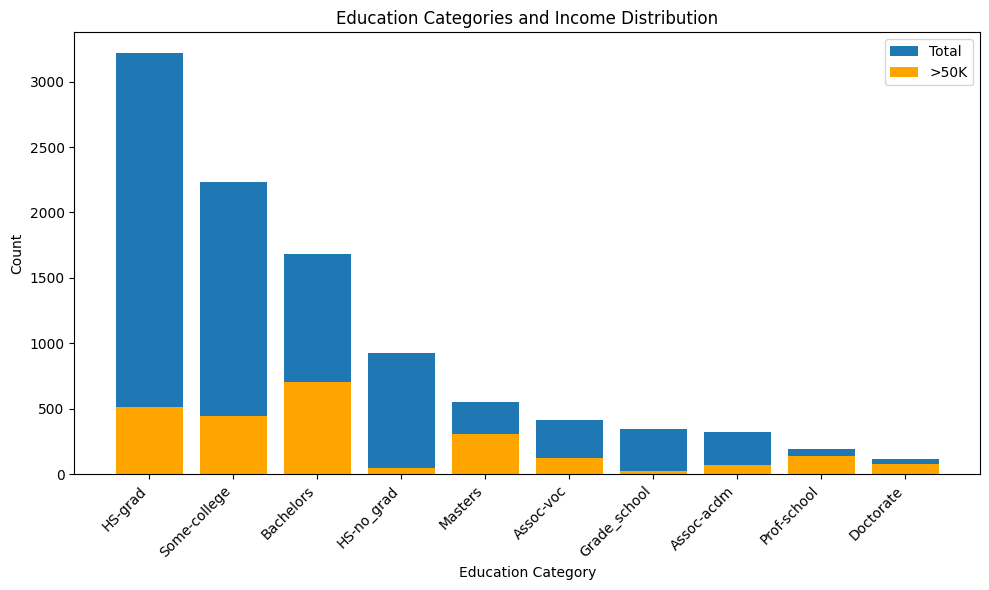

In [ ]:

education_counts = data.groupby('education')['income'].count().sort_values(ascending=False)
education_over_50k = data[data['income'] == '>50K'].groupby('education')['income'].count()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(education_counts.index, education_counts.values, label='Total')
ax.bar(education_over_50k.index, education_over_50k.values, label='>50K', color='orange')

ax.set_xlabel('Education Category')
ax.set_ylabel('Count')
ax.set_title('Education Categories and Income Distribution')
ax.legend()

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

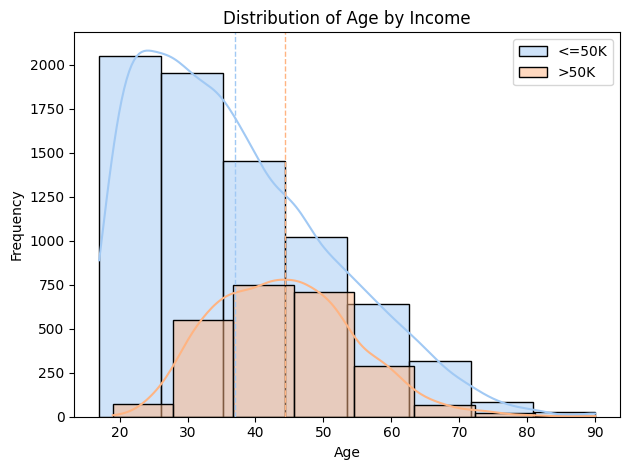

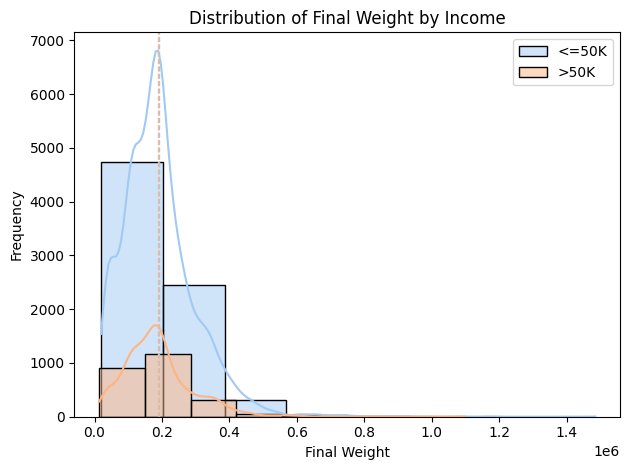

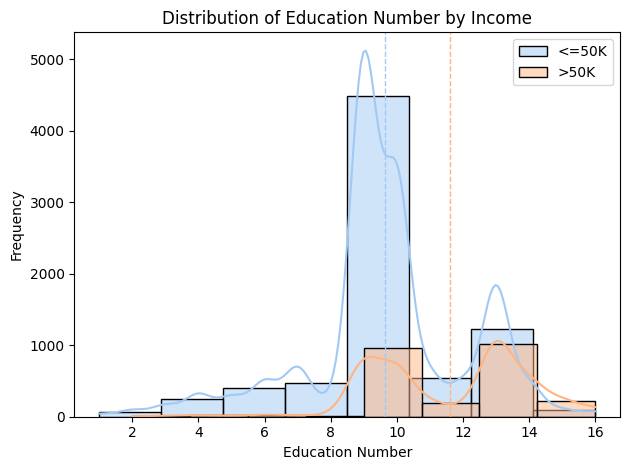

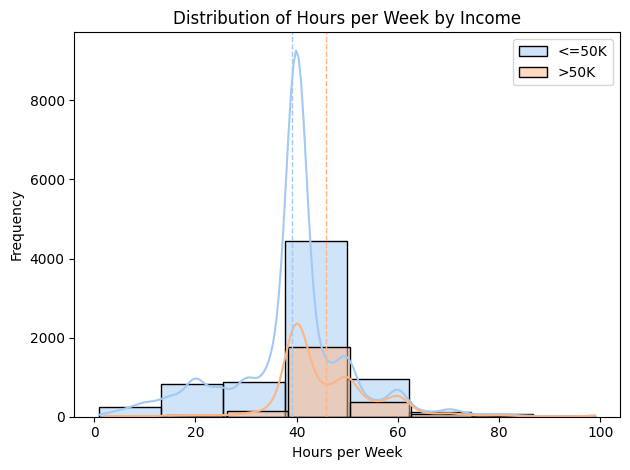

In [ ]:
def plot_overlapping_histograms(data, column, title, xlabel, bins=None, binrange=None):

    under_50k = data[data['income'] == '<=50K']
    over_50k = data[data['income'] == '>50K']
    bins=8
    sns.histplot(under_50k[column], kde=True, color=sns.color_palette("pastel")[0], label='<=50K', bins=bins, binrange=binrange)
    sns.histplot(over_50k[column], kde=True, color=sns.color_palette("pastel")[1], label='>50K', bins=bins, binrange=binrange)

    plt.axvline(under_50k[column].mean(), color=sns.color_palette("pastel")[0], linestyle='dashed', linewidth=1)
    plt.axvline(over_50k[column].mean(), color=sns.color_palette("pastel")[1], linestyle='dashed', linewidth=1)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_overlapping_histograms(data, 'age', 'Distribution of Age by Income', 'Age')
plot_overlapping_histograms(data, 'fnlwgt', 'Distribution of Final Weight by Income', 'Final Weight')

bins_edu = np.arange(data['education-num'].min(), data['education-num'].max() + 2, 1)  # Bins of width 1
plot_overlapping_histograms(data, 'education-num', 'Distribution of Education Number by Income', 'Education Number', bins=bins_edu)

bins_hours = np.arange(data['hours-per-week'].min(), data['hours-per-week'].max() + 5, 5)  # Bins of width 5
plot_overlapping_histograms(data, 'hours-per-week', 'Distribution of Hours per Week by Income', 'Hours per Week', bins=bins_hours)

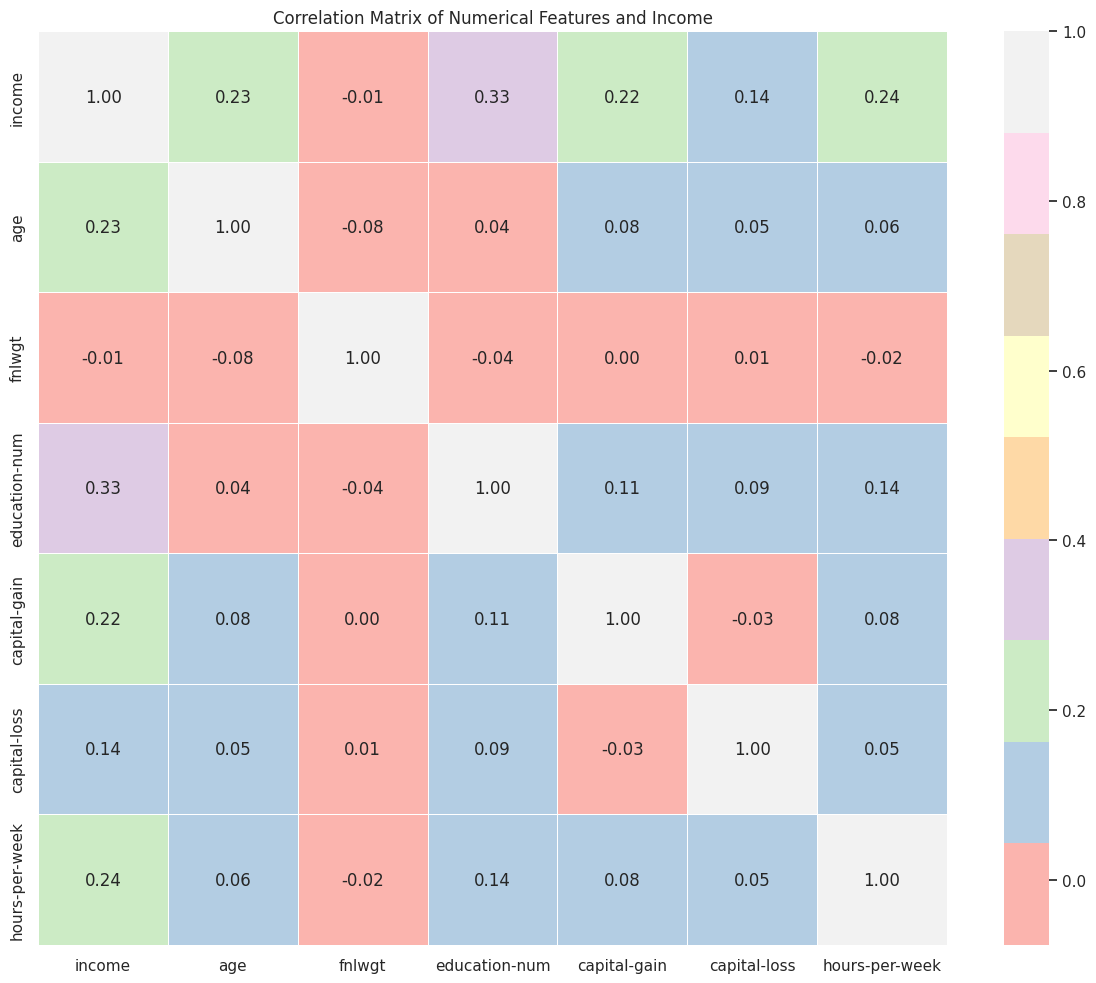

In [ ]:
from sklearn.preprocessing import LabelEncoder

numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']
numerical_data = data[numerical_features]

le = LabelEncoder()
numerical_data['income'] = le.fit_transform(numerical_data['income'])

correlation_matrix = numerical_data.corr()

cols = ['income'] + [col for col in correlation_matrix.columns if col != 'income']
correlation_matrix = correlation_matrix[cols].reindex(cols)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="Pastel1", fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Income')
plt.tight_layout()
plt.show()

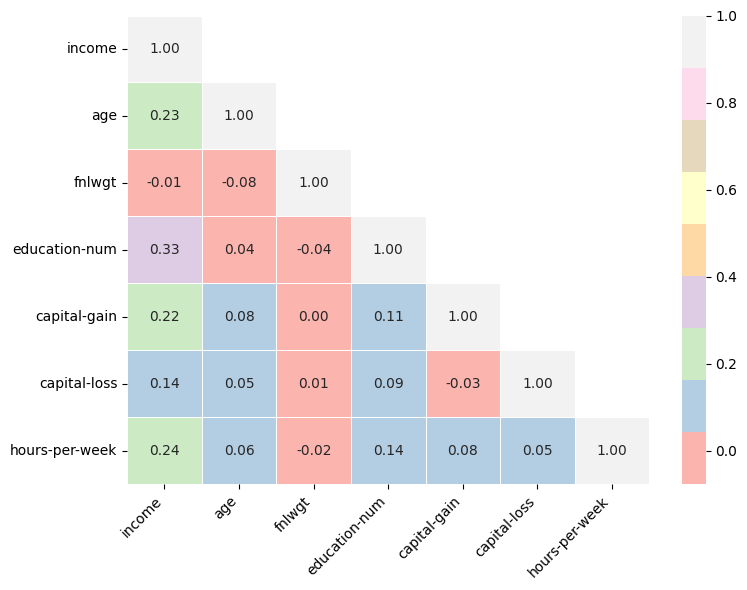

In [ ]:

from sklearn.preprocessing import LabelEncoder
numerical_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']
numerical_data = data[numerical_features]

le = LabelEncoder()
numerical_data['income'] = le.fit_transform(numerical_data['income'])

correlation_matrix = numerical_data.corr()

cols = ['income'] + [col for col in correlation_matrix.columns if col != 'income']
correlation_matrix = correlation_matrix[cols].reindex(cols)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)

plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="Pastel1", fmt=".2f", linewidths=.5, mask=mask)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()